# Unsupervised Learning Analysis of Gene Responses to Lin28a Knockdown

Instead of taking a hypothesis-driven approach by looking at known Lin28a targets, this analysis uses an **unsupervised machine learning** technique (K-Means Clustering). We blindly group genes based on their transcriptional (RNA) and translational (TE) responses to Lin28a knockdown (`siLin28a` vs `siLuc`).

After defining these response clusters mathematically, we map the Lin28a physical binding data (`CLIP-seq`) onto them to see if genes exhibiting specific response patterns (e.g., strong translation derepression) naturally correspond to Lin28a's direct physical targets. This complements the findings in Cho et al., 2012 by using a purely data-driven statistical approach.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy import stats

plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

## 1. Data Preprocessing and Metric Calculation
We load the read counts generated from the BAM files, filter out low-expressed genes to minimize noise, and compute the Translation Efficiency Log2 Fold Change (`TE_LFC`) and RNA Log2 Fold Change (`RNA_LFC`).

In [2]:
# Load read counts
df = pd.read_csv('binfo1-datapack1/read-counts.txt', sep='\t', comment='#')

# Rename columns
df = df.rename(columns={
    'CLIP-35L33G.bam': 'CLIP',
    'RNA-control.bam': 'RNA_control',
    'RNA-siLin28a.bam': 'RNA_siLin28a',
    'RNA-siLuc.bam': 'RNA_siLuc',
    'RPF-siLin28a.bam': 'RPF_siLin28a',
    'RPF-siLuc.bam': 'RPF_siLuc'
})

# Filter genes with at least 30 reads in relevant samples
mask = (df['RNA_siLin28a'] >= 30) & (df['RNA_siLuc'] >= 30) & (df['RPF_siLin28a'] >= 30) & (df['RPF_siLuc'] >= 30)
filtered_df = df[mask].copy()
print(f"Number of genes after filtering: {len(filtered_df)}")

# Calculate TE (Translation Efficiency)
filtered_df['TE_siLuc'] = (filtered_df['RPF_siLuc'] + 1) / (filtered_df['RNA_siLuc'] + 1)
filtered_df['TE_siLin28a'] = (filtered_df['RPF_siLin28a'] + 1) / (filtered_df['RNA_siLin28a'] + 1)

# Calculate Log2 Fold Changes
filtered_df['TE_LFC'] = np.log2(filtered_df['TE_siLin28a'] / filtered_df['TE_siLuc'])
filtered_df['RNA_LFC'] = np.log2((filtered_df['RNA_siLin28a'] + 1) / (filtered_df['RNA_siLuc'] + 1))
filtered_df['CLIP_log1p'] = np.log1p(filtered_df['CLIP'])

filtered_df[['Geneid', 'RNA_LFC', 'TE_LFC', 'CLIP']].head()

Number of genes after filtering: 9492


,Geneid,RNA_LFC,TE_LFC,CLIP
30,ENSMUSG00000103922.2,-0.103623,-0.718040,183
31,ENSMUSG00000033845.14,0.237585,-1.016743,4014
33,ENSMUSG00000025903.15,-0.019964,-0.384426,2045
35,ENSMUSG00000033813.16,-0.062923,-0.827799,1658
43,ENSMUSG00000033793.13,0.289125,-1.191550,1111


## 2. K-Means Clustering of Gene Responses
We cluster the genes into 4 distinct groups based solely on their `[RNA_LFC, TE_LFC]` vectors. We standardize the data first so both axes contribute equally to the distance metric.

In [3]:
# Prepare data for clustering
features = filtered_df[['RNA_LFC', 'TE_LFC']].values
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Perform K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(features_scaled)

filtered_df['Response_Cluster'] = [f'Cluster {c+1}' for c in clusters]
print("Genes per cluster:")
print(filtered_df['Response_Cluster'].value_counts())

Genes per cluster:
Response_Cluster
Cluster 3    3421
Cluster 2    2206
Cluster 4    2101
Cluster 1    1764
Name: count, dtype: int64


## 3. Visualizing the Clusters
Let's see how the K-Means algorithm segmented the cellular response space.

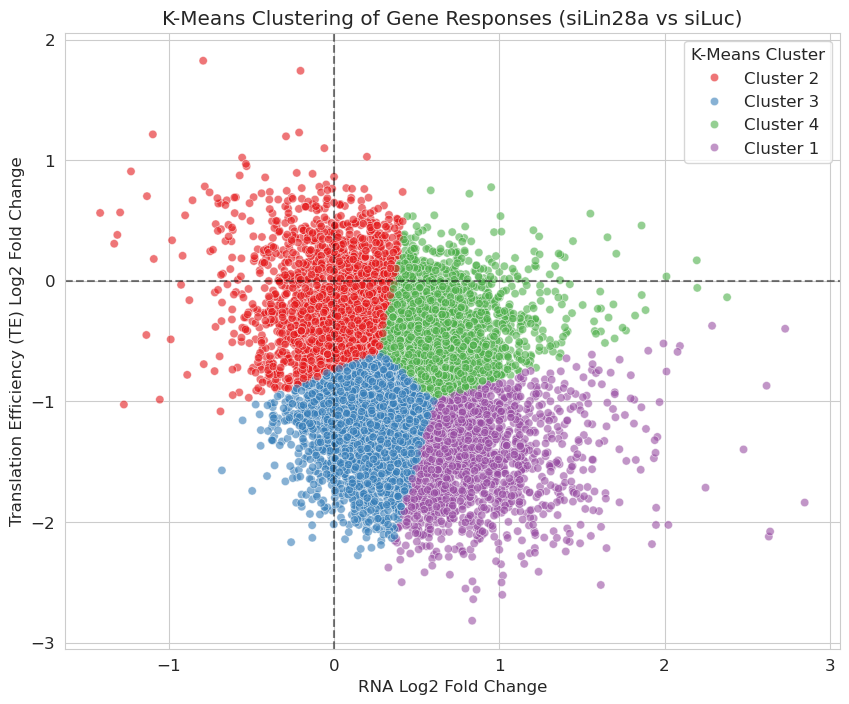

In [4]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=filtered_df,
    x='RNA_LFC',
    y='TE_LFC',
    hue='Response_Cluster',
    palette='Set1',
    alpha=0.6
)
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('K-Means Clustering of Gene Responses (siLin28a vs siLuc)')
plt.xlabel('RNA Log2 Fold Change')
plt.ylabel('Translation Efficiency (TE) Log2 Fold Change')
plt.legend(title='K-Means Cluster')
plt.show()

## 4. Lin28a Binding (CLIP-seq) Enrichment per Cluster
Now, without having given the model any information about Lin28a binding, we map the CLIP-seq counts back onto the clusters to see if any specific response cluster is enriched for Lin28a targets.

/tmp/ipykernel_5751/1314307168.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


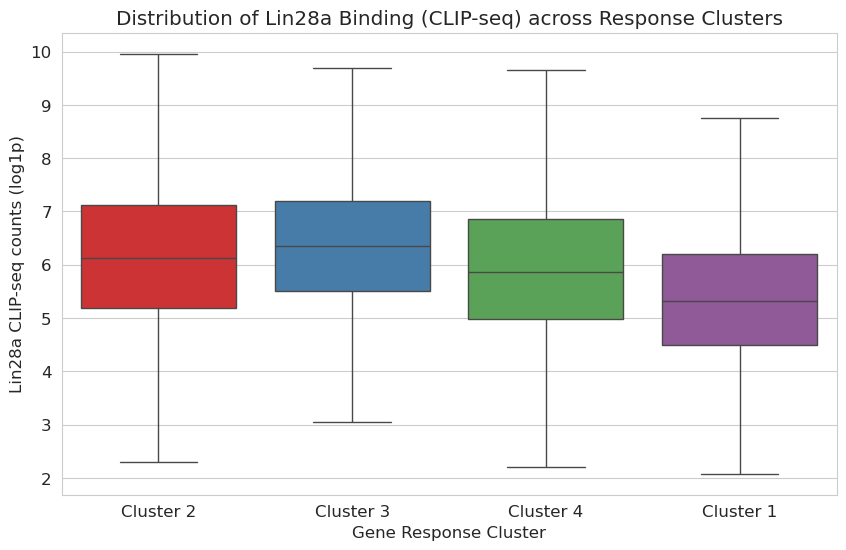

Kruskal-Wallis H-test across clusters: H-statistic = 635.18, p-value = 2.38e-137

Conclusion: The Lin28a binding levels are significantly different across the unsupervised response clusters!


In [5]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=filtered_df,
    x='Response_Cluster',
    y='CLIP_log1p',
    palette='Set1',
    showfliers=False
)
plt.title('Distribution of Lin28a Binding (CLIP-seq) across Response Clusters')
plt.xlabel('Gene Response Cluster')
plt.ylabel('Lin28a CLIP-seq counts (log1p)')
plt.show()

# Statistical Validation: Kruskal-Wallis H-test
cluster_groups = [group['CLIP'].values for name, group in filtered_df.groupby('Response_Cluster')]
H, pval = stats.kruskal(*cluster_groups)

print(f"Kruskal-Wallis H-test across clusters: H-statistic = {H:.2f}, p-value = {pval:.2e}")
if pval < 0.05:
    print("\nConclusion: The Lin28a binding levels are significantly different across the unsupervised response clusters!")
else:
    print("\nConclusion: No significant difference in Lin28a binding across clusters.")